# Lab OLAP 
## Estudiante Haider Johan Arango Diaz - Cod: 160004613



## Desafío 1

Construya un modelo de esquema tipo Estrella para operaciones OLAP usando `vgsales.csv`, con preprocesamiento e imputación por mediana para valores perdidos.

Realice las consultas:
- Ventas totales por género.
- Suma de ventas globales para `Genre = 'Action'`.
- Promedio, mínimo y máximo de ventas por año según editor y gráfico del promedio por año por editor.
- Ventas por trimestre en el último año para Estados Unidos, Japón y Europa.
- Nombre del juego y género con mayores ventas globales.

In [23]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

vgsales_path = 'vgsales.csv'
conn1 = sqlite3.connect(':memory:')

In [24]:
df = pd.read_csv(vgsales_path)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
num_cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    df[c] = df[c].fillna(df[c].median())
df['Year'] = df['Year'].round().astype(int)
df['quarter'] = ((df['Rank'].astype(int) - 1) % 4) + 1
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,quarter
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,1
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,2
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,3
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,4
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,1


In [36]:
dim_platform = df[['Platform']].drop_duplicates().reset_index(drop=True)
dim_platform['platform_id'] = dim_platform.index + 1
dim_platform = dim_platform.rename(columns={'Platform': 'platform_name'})

dim_genre = df[['Genre']].drop_duplicates().reset_index(drop=True)
dim_genre['genre_id'] = dim_genre.index + 1
dim_genre = dim_genre.rename(columns={'Genre': 'genre_name'})

dim_publisher = df[['Publisher']].fillna('Unknown').drop_duplicates().reset_index(drop=True)
dim_publisher['publisher_id'] = dim_publisher.index + 1
dim_publisher = dim_publisher.rename(columns={'Publisher': 'publisher_name'})

game_base = df[['Name', 'Platform', 'Genre', 'Publisher']].fillna('Unknown').drop_duplicates().reset_index(drop=True)
game_base = game_base.merge(
    dim_platform.rename(columns={'platform_name': 'Platform'})[['platform_id', 'Platform']],
    on='Platform',
    how='left'
)
game_base = game_base.merge(
    dim_genre.rename(columns={'genre_name': 'Genre'})[['genre_id', 'Genre']],
    on='Genre',
    how='left'
)
game_base = game_base.merge(
    dim_publisher.rename(columns={'publisher_name': 'Publisher'})[['publisher_id', 'Publisher']],
    on='Publisher',
    how='left'
)

dim_game = game_base[['Name', 'Platform', 'Genre', 'Publisher', 'platform_id', 'genre_id', 'publisher_id']].copy()
dim_game['game_id'] = dim_game.index + 1
dim_game = dim_game.rename(columns={'Name': 'game_name'})

dim_year = df[['Year', 'quarter']].drop_duplicates().reset_index(drop=True)
dim_year['year_id'] = dim_year.index + 1
dim_year = dim_year.rename(columns={'Year': 'year'})

fact_source = df.copy()
fact_source['Publisher'] = fact_source['Publisher'].fillna('Unknown')

fact = fact_source.merge(
    dim_game.rename(columns={'game_name': 'Name'})[
        ['game_id', 'Name', 'Platform', 'Genre', 'Publisher', 'platform_id', 'genre_id', 'publisher_id']
    ],
    on=['Name', 'Platform', 'Genre', 'Publisher'],
    how='left'
)
fact = fact.merge(
    dim_year[['year_id', 'year', 'quarter']],
    left_on=['Year', 'quarter'],
    right_on=['year', 'quarter'],
    how='left'
)

fact_sales = fact[['Rank', 'game_id', 'year_id', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].copy()
fact_sales.columns = ['sale_id', 'game_id', 'year_id', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'global_sales']

dim_platform[['platform_id', 'platform_name']].to_sql('dim_platform', conn1, if_exists='replace', index=False)
dim_genre[['genre_id', 'genre_name']].to_sql('dim_genre', conn1, if_exists='replace', index=False)
dim_publisher[['publisher_id', 'publisher_name']].to_sql('dim_publisher', conn1, if_exists='replace', index=False)
dim_game[['game_id', 'game_name', 'platform_id', 'genre_id', 'publisher_id']].to_sql('dim_game', conn1, if_exists='replace', index=False)
dim_year[['year_id', 'year', 'quarter']].to_sql('dim_year', conn1, if_exists='replace', index=False)
fact_sales.to_sql('fact_sales', conn1, if_exists='replace', index=False)

pd.read_sql_query('SELECT COUNT(*) AS rows_fact FROM fact_sales', conn1)

,rows_fact
0,16598


In [37]:
q_total_genre = '''
SELECT g.genre_name, ROUND(SUM(f.global_sales), 2) AS total_global_sales
FROM fact_sales f
JOIN dim_game gm ON f.game_id = gm.game_id
JOIN dim_genre g ON gm.genre_id = g.genre_id
GROUP BY g.genre_name
ORDER BY total_global_sales DESC;
'''

q_action = '''
SELECT ROUND(SUM(f.global_sales), 2) AS action_global_sales
FROM fact_sales f
JOIN dim_game gm ON f.game_id = gm.game_id
JOIN dim_genre g ON gm.genre_id = g.genre_id
WHERE g.genre_name = 'Action';
'''

print('Ventas totales por género:')
print(pd.read_sql_query(q_total_genre, conn1))
print('\nSuma de ventas globales para Action:')
print(pd.read_sql_query(q_action, conn1))

Ventas totales por género:
      genre_name  total_global_sales
0         Action             1751.18
1         Sports             1330.93
2        Shooter             1037.37
3   Role-Playing              927.37
4       Platform              831.37
5           Misc              809.96
6         Racing              732.04
7       Fighting              448.91
8     Simulation              392.20
9         Puzzle              244.95
10     Adventure              239.04
11      Strategy              175.12

Suma de ventas globales para Action:
   action_global_sales
0              1751.18


    year                publisher_name  avg_sales  min_sales  max_sales
0   1980                    Activision     0.6040       0.27       1.15
1   1980                         Atari     2.0900       0.24       4.31
2   1981  20th Century Fox Video Games     0.4500       0.22       0.79
3   1981                    Activision     1.4167       0.39       4.50
4   1981                         Atari     0.7682       0.13       1.97
5   1981                        Coleco     0.6975       0.34       1.46
6   1981                      Data Age     0.3900       0.39       0.39
7   1981                        Imagic     1.2050       0.37       2.13
8   1981            Mattel Interactive     0.3614       0.17       0.67
9   1981                  Men-A-Vision     0.7700       0.77       0.77
10  1981                      Mystique     0.8200       0.82       0.82
11  1981                  Parker Bros.     1.1167       0.22       2.20
12  1981                Starpath Corp.     0.3300       0.33    

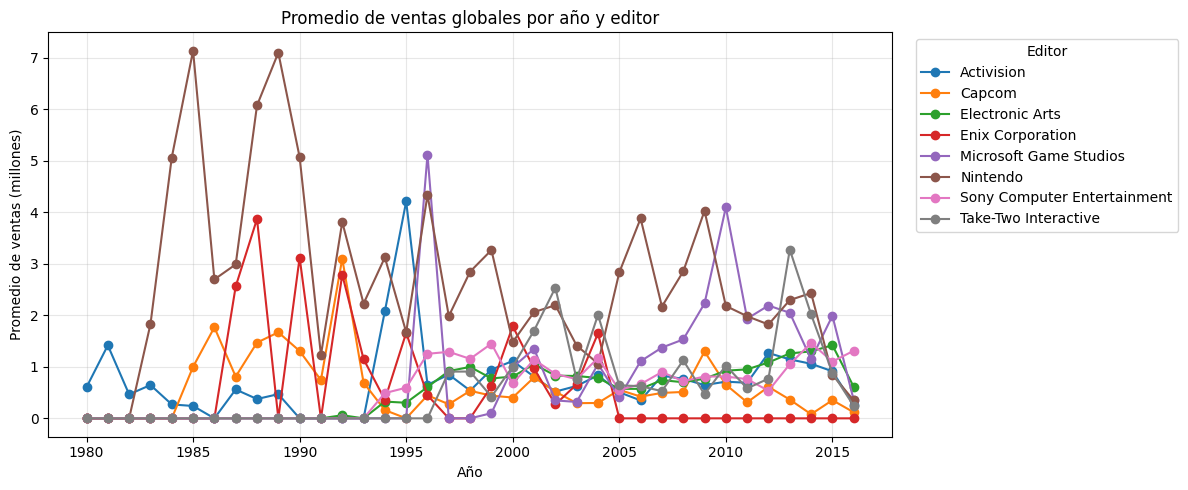

In [30]:
q_stats = '''
SELECT y.year, p.publisher_name,
       ROUND(AVG(f.global_sales), 4) AS avg_sales,
       ROUND(MIN(f.global_sales), 4) AS min_sales,
       ROUND(MAX(f.global_sales), 4) AS max_sales
FROM fact_sales f
JOIN dim_game gm ON f.game_id = gm.game_id
JOIN dim_publisher p ON gm.publisher_id = p.publisher_id
JOIN dim_year y ON f.year_id = y.year_id
GROUP BY y.year, p.publisher_name
ORDER BY y.year, p.publisher_name;
'''

stats = pd.read_sql_query(q_stats, conn1)
print(stats.head(20))

top_pub = stats.groupby('publisher_name', as_index=False)['avg_sales'].sum().sort_values('avg_sales', ascending=False).head(8)
plot_df = stats[stats['publisher_name'].isin(top_pub['publisher_name'])]
pivot_plot = plot_df.pivot_table(index='year', columns='publisher_name', values='avg_sales', aggfunc='mean').fillna(0)
pivot_plot.plot(figsize=(12, 5), marker='o')
plt.title('Promedio de ventas globales por año y editor')
plt.ylabel('Promedio de ventas (millones)')
plt.xlabel('Año')
plt.grid(True, alpha=0.3)
plt.legend(title='Editor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [38]:
q_quarter = '''
SELECT y.year, y.quarter,
       ROUND(SUM(f.na_sales), 2) AS na_sales,
       ROUND(SUM(f.jp_sales), 2) AS jp_sales,
       ROUND(SUM(f.eu_sales), 2) AS eu_sales
FROM fact_sales f
JOIN dim_year y ON f.year_id = y.year_id
WHERE y.year = (SELECT MAX(year) FROM dim_year)
GROUP BY y.year, y.quarter
ORDER BY y.quarter;
'''

q_top_game = '''
SELECT gm.game_name, g.genre_name, ROUND(f.global_sales, 2) AS global_sales
FROM fact_sales f
JOIN dim_game gm ON f.game_id = gm.game_id
JOIN dim_genre g ON gm.genre_id = g.genre_id
ORDER BY f.global_sales DESC
LIMIT 1;
'''

print('Ventas por trimestre (trimestre sintético) en el último año para NA, JP y EU:')
print(pd.read_sql_query(q_quarter, conn1))
print('\nJuego y género con mayores ventas globales:')
print(pd.read_sql_query(q_top_game, conn1))

Ventas por trimestre (trimestre sintético) en el último año para NA, JP y EU:
   year  quarter  na_sales  jp_sales  eu_sales
0  2020        3      0.27       0.0       0.0

Juego y género con mayores ventas globales:
    game_name genre_name  global_sales
0  Wii Sports     Sports         82.74


## Desafío 2

- Defina el modelo de datos con `sqlite3`.
- Realice operaciones OLAP:
  1. Drill-down de detalle para `Long Term Debt`.
  2. Roll-up con resumen en nivel superior.
  3. Slice and Dice para `Fiscal Year = 2010`.

In [39]:
ibrd_path = 'IBRD_Balance_Sheet__FY2010.csv'
conn2 = sqlite3.connect(':memory:')

ib = pd.read_csv(ibrd_path)
ib = ib.rename(columns={
    'Category Code': 'category_code',
    'Category': 'category',
    'Subcategory Code': 'subcategory_code',
    'Subcategory': 'subcategory',
    'Line Item': 'line_item',
    'Fiscal Year': 'fiscal_year',
    'Amount (US$, Millions)': 'amount_usd_millions'
})
ib['fiscal_year'] = pd.to_numeric(ib['fiscal_year'], errors='coerce')
ib['amount_usd_millions'] = pd.to_numeric(ib['amount_usd_millions'], errors='coerce')
ib['fiscal_year'] = ib['fiscal_year'].fillna(ib['fiscal_year'].median()).round().astype(int)
ib['amount_usd_millions'] = ib['amount_usd_millions'].fillna(ib['amount_usd_millions'].median())
ib.head()

,category_code,category,subcategory_code,subcategory,line_item,fiscal_year,amount_usd_millions
0,a,Assets,dfb,Due from Banks,Unrestricted currencies,2010,1581
1,a,Assets,dfb,Due from Banks,Unrestricted currencies,2009,2380
2,a,Assets,dfb,Due from Banks,Currencies subject to restriction,2010,222
3,a,Assets,dfb,Due from Banks,Currencies subject to restriction,2009,664
4,a,Assets,i,Investments,Trading,2010,36012


In [40]:
dim_category = ib[['category_code', 'category']].drop_duplicates().reset_index(drop=True)
dim_category['category_id'] = dim_category.index + 1

dim_subcategory = ib[['subcategory_code', 'subcategory', 'category_code']].drop_duplicates().reset_index(drop=True)
dim_subcategory = dim_subcategory.merge(dim_category[['category_id', 'category_code']], on='category_code', how='left')
dim_subcategory['subcategory_id'] = dim_subcategory.index + 1

dim_year2 = ib[['fiscal_year']].drop_duplicates().reset_index(drop=True)
dim_year2['year_id'] = dim_year2.index + 1

fact_balance = ib.merge(dim_subcategory[['subcategory_id', 'subcategory_code']], on='subcategory_code', how='left')
fact_balance = fact_balance.merge(dim_year2[['year_id', 'fiscal_year']], on='fiscal_year', how='left')
fact_balance = fact_balance[['line_item', 'subcategory_id', 'year_id', 'amount_usd_millions']].copy()
fact_balance['record_id'] = fact_balance.index + 1
fact_balance = fact_balance[['record_id', 'line_item', 'subcategory_id', 'year_id', 'amount_usd_millions']]

dim_category[['category_id', 'category_code', 'category']].to_sql('dim_category', conn2, if_exists='replace', index=False)
dim_subcategory[['subcategory_id', 'subcategory_code', 'subcategory', 'category_id']].to_sql('dim_subcategory', conn2, if_exists='replace', index=False)
dim_year2[['year_id', 'fiscal_year']].to_sql('dim_year', conn2, if_exists='replace', index=False)
fact_balance.to_sql('fact_balance', conn2, if_exists='replace', index=False)

pd.read_sql_query('SELECT COUNT(*) AS rows_fact FROM fact_balance', conn2)

,rows_fact
0,72


In [41]:
q_drill = '''
SELECT c.category, s.subcategory, f.line_item, y.fiscal_year, f.amount_usd_millions
FROM fact_balance f
JOIN dim_subcategory s ON f.subcategory_id = s.subcategory_id
JOIN dim_category c ON s.category_id = c.category_id
JOIN dim_year y ON f.year_id = y.year_id
WHERE LOWER(f.line_item) LIKE '%long-term debt%' OR LOWER(f.line_item) LIKE '%long term debt%'
ORDER BY y.fiscal_year DESC, f.amount_usd_millions DESC;
'''

print('Drill-down para Long Term Debt:')
print(pd.read_sql_query(q_drill, conn2).head(20))

Drill-down para Long Term Debt:
Empty DataFrame
Columns: [category, subcategory, line_item, fiscal_year, amount_usd_millions]
Index: []


In [43]:
q_rollup = '''
SELECT c.category, y.fiscal_year, ROUND(SUM(f.amount_usd_millions), 2) AS total_amount
FROM fact_balance f
JOIN dim_subcategory s ON f.subcategory_id = s.subcategory_id
JOIN dim_category c ON s.category_id = c.category_id
JOIN dim_year y ON f.year_id = y.year_id
GROUP BY c.category, y.fiscal_year
ORDER BY y.fiscal_year, c.category;
'''

print('Roll-up por categoría y año fiscal:')
print(pd.read_sql_query(q_rollup, conn2))

Roll-up por categoría y año fiscal:
      category  fiscal_year  total_amount
0       Assets         2009      275779.0
1       Equity         2009      163102.0
2  Liabilities         2009      235383.0
3       Assets         2010      283323.0
4       Equity         2010      159181.0
5  Liabilities         2010      245455.0


In [35]:
q_slice_dice = '''
SELECT c.category, s.subcategory,
       ROUND(SUM(f.amount_usd_millions), 2) AS total_amount,
       ROUND(AVG(f.amount_usd_millions), 2) AS avg_amount
FROM fact_balance f
JOIN dim_subcategory s ON f.subcategory_id = s.subcategory_id
JOIN dim_category c ON s.category_id = c.category_id
JOIN dim_year y ON f.year_id = y.year_id
WHERE y.fiscal_year = 2010
GROUP BY c.category, s.subcategory
ORDER BY total_amount DESC;
'''

print('Slice and Dice para Fiscal Year 2010:')
print(pd.read_sql_query(q_slice_dice, conn2))

Slice and Dice para Fiscal Year 2010:
       category             subcategory  total_amount  avg_amount
0   Liabilities              Borrowings      128577.0   128577.00
1        Assets       Derivative Assets      121939.0    24387.80
2        Equity        Deferred Amounts      121939.0    24387.80
3        Assets       Loans Outstanding      118104.0   118104.00
4   Liabilities  Derivative Liabilities      110418.0    27604.50
5        Assets             Investments       36012.0    36012.00
6        Equity       Retained Earnings       28793.0    28793.00
7        Equity           Capital Stock       11492.0    11492.00
8   Liabilities       Other Liabilities        5454.0     1363.50
9        Assets            Other Assets        3071.0     1023.67
10       Assets          Due from Banks        1803.0      901.50
11       Assets           Nonnegotiable        1123.0     1123.00
12  Liabilities            Sold or Lent         998.0      998.00
13       Assets       Other Receivable

In [11]:
conn1.close()
conn2.close()